# 🏏 Pakistan ODI Cricket — End-to-End Data Science & Machine Learning

## Portfolio Project

This notebook uses the **actual CSV contained in the supplied `archive.zip`**.

### Objectives
- Data audit and cleaning
- Exploratory Data Analysis (EDA)
- Feature engineering
- Statistical performance analysis
- Classification and model comparison
- 5-fold cross-validation
- Feature importance
- Confusion matrix
- K-Means venue clustering
- Example match prediction

> **Data audit:** the supplied CSV contains **26 rows**, not 43, and spans **2015–2023**. Results below are based on the actual file.


In [1]:
import re, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, ConfusionMatrixDisplay
from sklearn.cluster import KMeans
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
print("Libraries loaded.")


Libraries loaded.


## 1. Load and Inspect

In [2]:
df=pd.read_csv("../data/ODI statistics in Pakistan 2019-23.csv")
print("Shape:",df.shape)
display(df.head())
display(df.dtypes)
display(df.isna().sum())
print("Duplicates:",df.duplicated().sum())


Shape: (26, 7)


,Team 1,Team 2,Format,Date,Venue,Result,Status
0,New Zealand299 (49.3 ov),Pakistan252 (46.1 ov),ODI,"May 07, 2023",Karachi,New Zealand,Completed
1,Pakistan334/6 (50.0 ov),New Zealand232 (43.4 ov),ODI,"May 05, 2023",Karachi,Pakistan,Completed
2,Pakistan287/6 (50.0 ov),New Zealand261 (49.1 ov),ODI,"May 03, 2023",Karachi,Pakistan,Completed
3,Pakistan280/9 (50.0 ov),New Zealand281/8 (48.1 ov),ODI,"Jan 13, 2023",Karachi,New Zealand,Completed
4,New Zealand261 (49.5 ov),Pakistan182 (43.0 ov),ODI,"Jan 11, 2023",Karachi,New Zealand,Completed


Team 1    object
Team 2    object
Format    object
Date      object
Venue     object
Result    object
Status    object
dtype: object

Team 1    0
Team 2    0
Format    0
Date      0
Venue     0
Result    0
Status    0
dtype: int64

Duplicates: 0


## 2. Data Quality Audit

In [3]:
df["Date"]=pd.to_datetime(df["Date"],format="mixed",errors="coerce")
print("Date range:",df["Date"].min().date(),"to",df["Date"].max().date())
print("Years:",sorted(df["Date"].dt.year.unique()))
print("\nResults:")
display(df["Result"].value_counts())
print("\nStatus:")
display(df["Status"].value_counts())


Date range: 2015-05-26 to 2023-09-06
Years: [np.int32(2015), np.int32(2019), np.int32(2020), np.int32(2021), np.int32(2022), np.int32(2023)]

Results:


Result
Pakistan       14
New Zealand     3
CANCELED        3
Sri Lanka       1
ABANDONED       1
Bangladesh      1
Australia       1
NR              1
Zimbabwe        1
Name: count, dtype: int64


Status:


Status
Completed    26
Name: count, dtype: int64

### Audit finding

The actual CSV has **26 records**. Five are non-decisive (`ABANDONED`, `CANCELED`, or `NR`), leaving **21 decisive matches** for the binary prediction problem. The dates actually span **2015–2023**.


## 3. Feature Engineering

In [4]:
def parse_innings_cell(value):
    s=str(value).strip()
    m=re.match(r"^(.*?)(\d+(?:/\d+)?)(?:\s*\(([\d.]+)\s*ov\))?$",s)
    if not m: return pd.Series([s,np.nan,np.nan])
    return pd.Series([m.group(1).strip(),int(m.group(2).split("/")[0]),float(m.group(3)) if m.group(3) else np.nan])

for col,prefix in [("Team 1","Team1"),("Team 2","Team2")]:
    df[[f"{prefix}_name",f"{prefix}_runs",f"{prefix}_overs"]]=df[col].apply(parse_innings_cell)

def overs_to_balls(x):
    if pd.isna(x): return np.nan
    s=str(x)
    if "." in s:
        o,b=s.split("."); return int(o)*6+int(b)
    return int(float(s))

df["Team1_balls"]=df["Team1_overs"].apply(overs_to_balls)
df["Team2_balls"]=df["Team2_overs"].apply(overs_to_balls)
df["Pakistan_batted_first"]=(df["Team1_name"].str.lower()=="pakistan").astype(int)
df["Opponent"]=np.where(df["Team1_name"].str.lower()=="pakistan",df["Team2_name"],df["Team1_name"])
df["Total_runs"]=df["Team1_runs"]+df["Team2_runs"]
df["Pakistan_win"]=(df["Result"].str.lower()=="pakistan").astype(int)
df["Decisive"]=df["Result"].isin(["Pakistan","New Zealand","Sri Lanka","Bangladesh","Australia","Zimbabwe"])
df["Year"]=df["Date"].dt.year
df["Month"]=df["Date"].dt.month
df["DayOfWeek"]=df["Date"].dt.dayofweek
display(df[["Team 1","Team 2","Opponent","Team1_runs","Team2_runs","Pakistan_batted_first","Pakistan_win","Decisive"]].head(10))


,Team 1,Team 2,Opponent,Team1_runs,Team2_runs,Pakistan_batted_first,Pakistan_win,Decisive
0,New Zealand299 (49.3 ov),Pakistan252 (46.1 ov),New Zealand,299.0,252.0,0,0,True
1,Pakistan334/6 (50.0 ov),New Zealand232 (43.4 ov),New Zealand,334.0,232.0,1,1,True
2,Pakistan287/6 (50.0 ov),New Zealand261 (49.1 ov),New Zealand,287.0,261.0,1,1,True
3,Pakistan280/9 (50.0 ov),New Zealand281/8 (48.1 ov),New Zealand,280.0,281.0,1,0,True
4,New Zealand261 (49.5 ov),Pakistan182 (43.0 ov),New Zealand,261.0,182.0,0,0,True
5,New Zealand255/9 (50.0 ov),Pakistan258/4 (48.1 ov),New Zealand,255.0,258.0,0,1,True
6,Sri Lanka297/9 (50.0 ov),Pakistan299/5 (48.2 ov),Sri Lanka,297.0,299.0,0,1,True
7,Pakistan305/7 (50.0 ov),Sri Lanka238 (46.5 ov),Sri Lanka,305.0,238.0,1,1,True
8,Pakistan,Sri Lanka,Sri Lanka,NaN,NaN,1,0,False
9,Bangladesh197 (38.5 ov),Pakistan194/3 (39.3 ov),Bangladesh,197.0,194.0,0,1,True


## 4. Exploratory Data Analysis

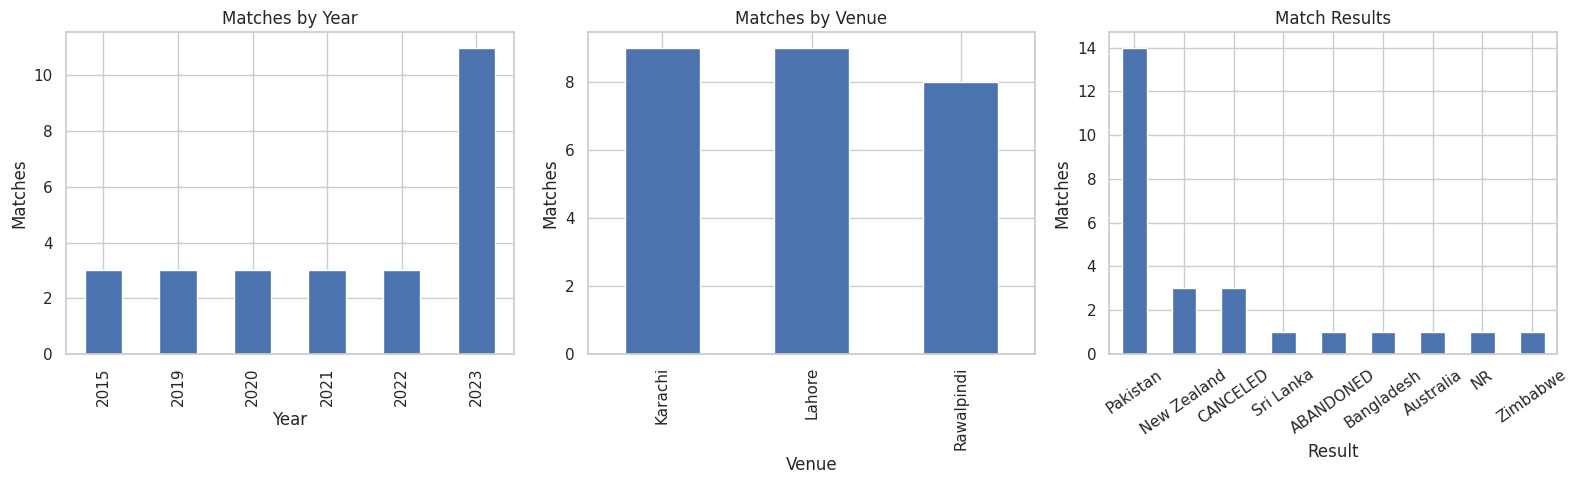

In [5]:
fig,axes=plt.subplots(1,3,figsize=(16,5))
df["Year"].value_counts().sort_index().plot(kind="bar",ax=axes[0]); axes[0].set_title("Matches by Year"); axes[0].set_xlabel("Year"); axes[0].set_ylabel("Matches")
df["Venue"].value_counts().plot(kind="bar",ax=axes[1]); axes[1].set_title("Matches by Venue"); axes[1].set_xlabel("Venue"); axes[1].set_ylabel("Matches")
df["Result"].value_counts().plot(kind="bar",ax=axes[2]); axes[2].set_title("Match Results"); axes[2].set_xlabel("Result"); axes[2].set_ylabel("Matches"); axes[2].tick_params(axis="x",rotation=35)
plt.tight_layout(); plt.show()


,Matches,Wins,Win_Rate
Opponent,,,
Zimbabwe,5,4,80.000000
Australia,3,2,66.666667
Sri Lanka,3,2,66.666667
New Zealand,8,5,62.500000
Bangladesh,2,1,50.000000


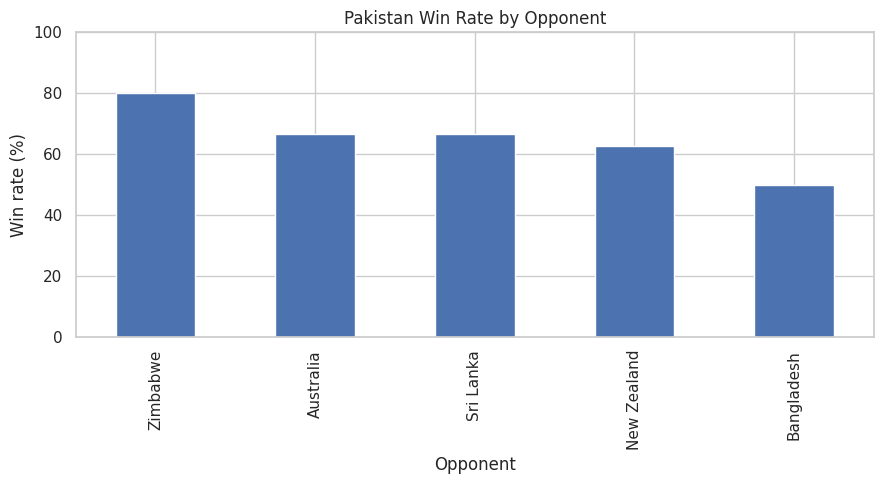

In [6]:
eligible=df[df["Decisive"]].copy()
opponent_stats=eligible.groupby("Opponent")["Pakistan_win"].agg(Matches="count",Wins="sum")
opponent_stats["Win_Rate"]=opponent_stats["Wins"]/opponent_stats["Matches"]*100
display(opponent_stats.sort_values("Win_Rate",ascending=False))
opponent_stats["Win_Rate"].sort_values(ascending=False).plot(kind="bar",figsize=(9,5))
plt.title("Pakistan Win Rate by Opponent"); plt.xlabel("Opponent"); plt.ylabel("Win rate (%)"); plt.ylim(0,100); plt.tight_layout(); plt.show()


,Matches,Avg_Total_Runs,Pakistan_Wins,Win_Rate
Venue,,,,
Rawalpindi,5,550.600,4,80.0
Karachi,8,540.125,5,62.5
Lahore,8,556.750,5,62.5


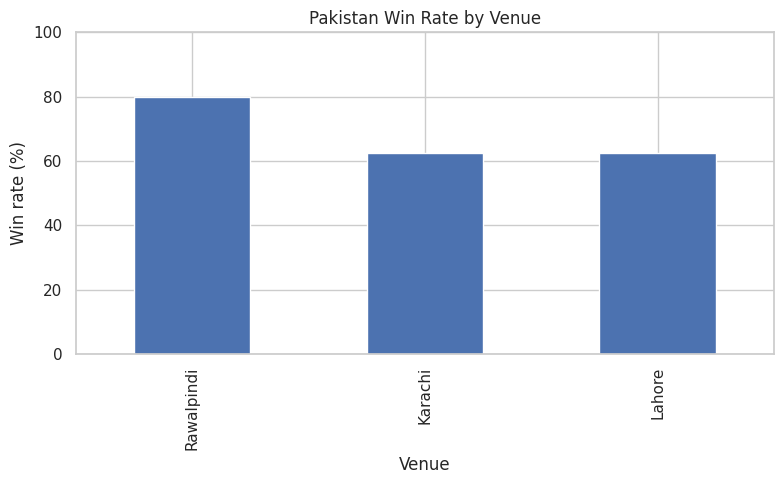

In [7]:
venue_stats=eligible.groupby("Venue").agg(Matches=("Venue","count"),Avg_Total_Runs=("Total_runs","mean"),Pakistan_Wins=("Pakistan_win","sum"))
venue_stats["Win_Rate"]=venue_stats["Pakistan_Wins"]/venue_stats["Matches"]*100
display(venue_stats.sort_values("Win_Rate",ascending=False))
venue_stats["Win_Rate"].sort_values(ascending=False).plot(kind="bar",figsize=(8,5))
plt.title("Pakistan Win Rate by Venue"); plt.xlabel("Venue"); plt.ylabel("Win rate (%)"); plt.ylim(0,100); plt.tight_layout(); plt.show()


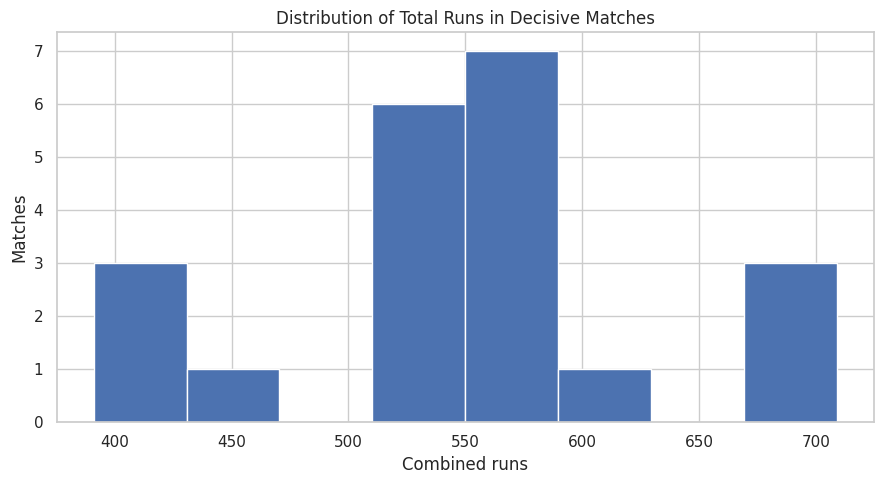

In [8]:
plt.figure(figsize=(9,5))
plt.hist(eligible["Total_runs"].dropna(),bins=8)
plt.title("Distribution of Total Runs in Decisive Matches")
plt.xlabel("Combined runs"); plt.ylabel("Matches"); plt.tight_layout(); plt.show()


## 5. Machine Learning

The classifier uses **pre-match-style context features** rather than final innings scores: opponent, venue, year, month, and whether Pakistan batted first. This avoids the most obvious target leakage.

In [9]:
features=["Opponent","Venue","Year","Month","Pakistan_batted_first"]
X=eligible[features]; y=eligible["Pakistan_win"]
display(y.value_counts())
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=.25,random_state=42,stratify=y)

preprocessor=ColumnTransformer([
    ("categorical",OneHotEncoder(handle_unknown="ignore"),["Opponent","Venue"]),
    ("numeric",StandardScaler(),["Year","Month","Pakistan_batted_first"])
])
model_defs={
    "Logistic Regression":LogisticRegression(max_iter=2000),
    "Decision Tree":DecisionTreeClassifier(max_depth=3,random_state=42),
    "Random Forest":RandomForestClassifier(n_estimators=500,max_depth=4,random_state=42,class_weight="balanced"),
    "Gradient Boosting":GradientBoostingClassifier(random_state=42)
}


Pakistan_win
1    14
0     7
Name: count, dtype: int64

## 6. Holdout Model Scores

In [10]:
rows=[]; pipelines={}
for name,est in model_defs.items():
    pipe=Pipeline([("preprocessor",preprocessor),("model",est)])
    pipe.fit(X_train,y_train); pred=pipe.predict(X_test); pipelines[name]=pipe
    rows.append([name,accuracy_score(y_test,pred),precision_score(y_test,pred,zero_division=0),recall_score(y_test,pred,zero_division=0),f1_score(y_test,pred,zero_division=0)])
holdout_results=pd.DataFrame(rows,columns=["Model","Accuracy","Precision","Recall","F1 Score"])
display(holdout_results)


,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.666667,0.666667,1.0,0.8
1,Decision Tree,0.666667,0.666667,1.0,0.8
2,Random Forest,0.666667,0.666667,1.0,0.8
3,Gradient Boosting,0.666667,0.666667,1.0,0.8


## 7. 5-Fold Cross-Validation

,Model,CV Accuracy,CV Precision,CV Recall,CV F1
3,Gradient Boosting,0.52,0.670000,0.700000,0.634762
2,Random Forest,0.52,0.670000,0.700000,0.634762
0,Logistic Regression,0.52,0.503333,0.733333,0.588095
1,Decision Tree,0.51,0.500000,0.633333,0.556190


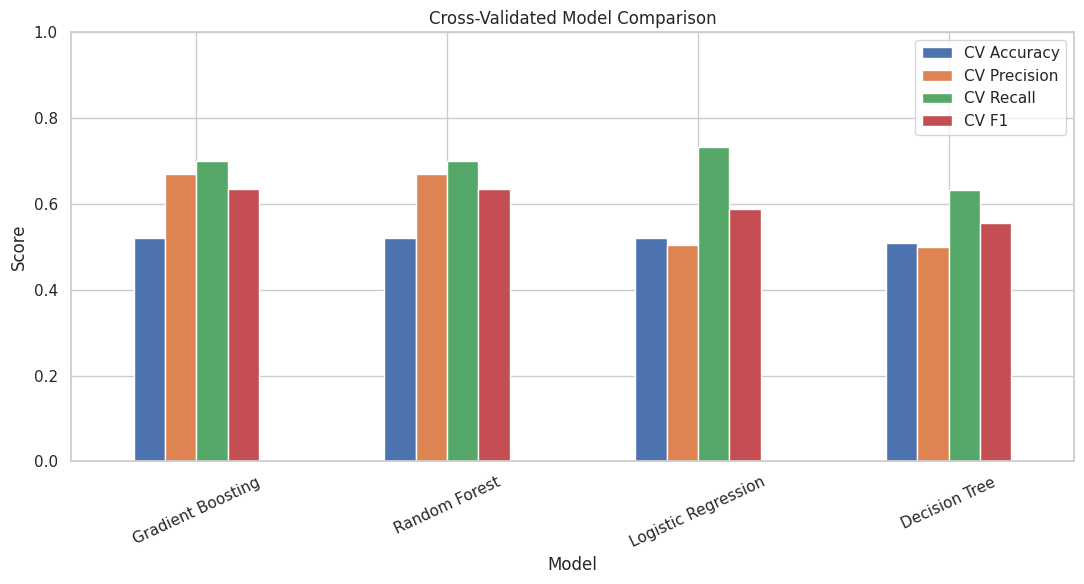

In [11]:
cv=StratifiedKFold(n_splits=5,shuffle=True,random_state=42)
rows=[]
for name,est in model_defs.items():
    pipe=Pipeline([("preprocessor",preprocessor),("model",est)])
    scores=cross_validate(pipe,X,y,cv=cv,scoring=["accuracy","precision","recall","f1"],error_score="raise")
    rows.append([name,scores["test_accuracy"].mean(),scores["test_precision"].mean(),scores["test_recall"].mean(),scores["test_f1"].mean()])
cv_results=pd.DataFrame(rows,columns=["Model","CV Accuracy","CV Precision","CV Recall","CV F1"]).sort_values("CV F1",ascending=False)
display(cv_results)
cv_results.set_index("Model")[["CV Accuracy","CV Precision","CV Recall","CV F1"]].plot(kind="bar",figsize=(11,6))
plt.title("Cross-Validated Model Comparison"); plt.ylabel("Score"); plt.ylim(0,1); plt.xticks(rotation=25); plt.tight_layout(); plt.show()


**Interpretation:** with only 21 decisive matches, these metrics are exploratory. Cross-validation is included to show proper evaluation practice, but the project should not claim production-level predictive accuracy.

## 8. Feature Importance

Best model by mean CV F1: Gradient Boosting


,Feature,Importance
9,numeric__Month,0.345713
8,numeric__Year,0.227413
10,numeric__Pakistan_batted_first,0.175533
3,categorical__Opponent_Sri Lanka,0.105429
7,categorical__Venue_Rawalpindi,0.072199
2,categorical__Opponent_New Zealand,0.046668
5,categorical__Venue_Karachi,0.023065
6,categorical__Venue_Lahore,0.002879
0,categorical__Opponent_Australia,0.000999
1,categorical__Opponent_Bangladesh,0.000101


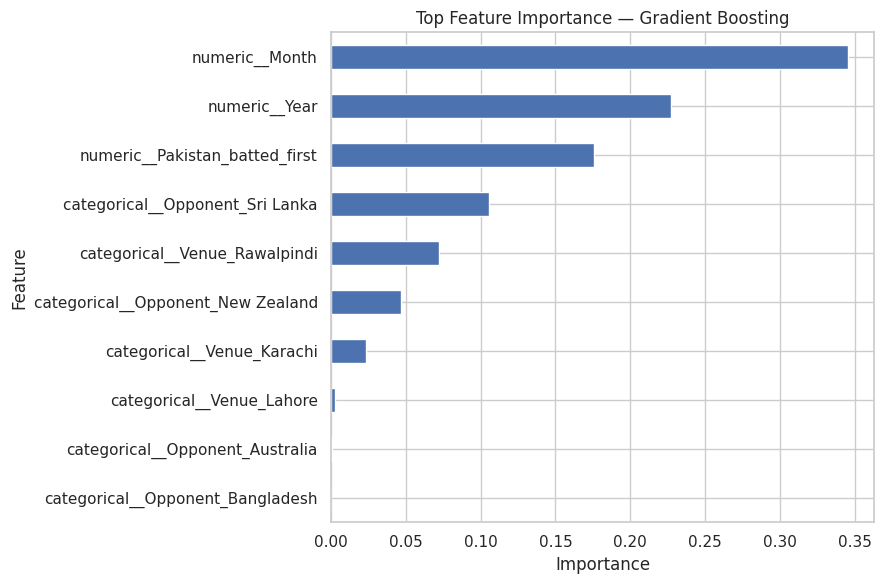

In [12]:
best_model_name=cv_results.iloc[0]["Model"]
print("Best model by mean CV F1:",best_model_name)
final_model=Pipeline([("preprocessor",preprocessor),("model",model_defs[best_model_name])])
final_model.fit(X,y)
names=final_model.named_steps["preprocessor"].get_feature_names_out()
obj=final_model.named_steps["model"]
imp=obj.feature_importances_ if hasattr(obj,"feature_importances_") else np.abs(obj.coef_[0])
feature_importance=pd.DataFrame({"Feature":names,"Importance":imp}).sort_values("Importance",ascending=False)
display(feature_importance.head(15))
feature_importance.head(10).sort_values("Importance").plot(kind="barh",x="Feature",y="Importance",legend=False,figsize=(9,6))
plt.title(f"Top Feature Importance — {best_model_name}"); plt.xlabel("Importance"); plt.ylabel("Feature"); plt.tight_layout(); plt.show()


## 9. Holdout Predictions

,Opponent,Venue,Year,Month,Pakistan_batted_first,Actual,Predicted,Pakistan_Win_Probability
24,Zimbabwe,Rawalpindi,2020,11,0,1,1,0.929571
23,Zimbabwe,Rawalpindi,2020,11,0,0,1,0.929571
7,Sri Lanka,Karachi,2019,9,1,1,1,0.907026
17,Zimbabwe,Lahore,2015,5,1,1,1,0.903284
10,Sri Lanka,Lahore,2023,9,0,0,1,0.570810
12,Australia,Lahore,2022,4,0,1,0,0.448774


Random Forest holdout accuracy: 0.5


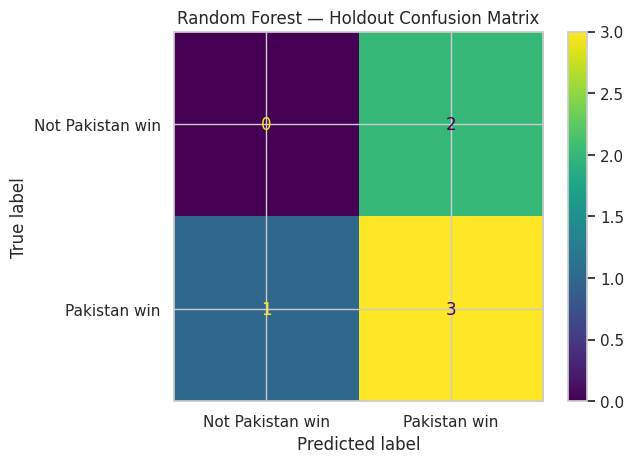

In [13]:
rf=pipelines["Random Forest"]
rf_pred=rf.predict(X_test); rf_prob=rf.predict_proba(X_test)[:,1]
prediction_table=X_test.copy()
prediction_table["Actual"]=y_test.values
prediction_table["Predicted"]=rf_pred
prediction_table["Pakistan_Win_Probability"]=rf_prob
display(prediction_table.sort_values("Pakistan_Win_Probability",ascending=False))
print("Random Forest holdout accuracy:",accuracy_score(y_test,rf_pred))
ConfusionMatrixDisplay.from_predictions(y_test,rf_pred,display_labels=["Not Pakistan win","Pakistan win"])
plt.title("Random Forest — Holdout Confusion Matrix"); plt.show()


## 10. K-Means Venue Clustering

In [14]:
cluster_features=venue_stats[["Matches","Avg_Total_Runs","Win_Rate"]]
cluster_X=StandardScaler().fit_transform(cluster_features)
venue_stats["Cluster"]=KMeans(n_clusters=min(3,len(cluster_features)),random_state=42,n_init=20).fit_predict(cluster_X)
display(venue_stats.sort_values("Cluster"))


,Matches,Avg_Total_Runs,Pakistan_Wins,Win_Rate,Cluster
Venue,,,,,
Lahore,8,556.750,5,62.5,0
Rawalpindi,5,550.600,4,80.0,1
Karachi,8,540.125,5,62.5,2


## 11. Example Prediction

In [15]:
prediction_cases=pd.DataFrame({
    "Opponent":["New Zealand","Australia","Zimbabwe"],
    "Venue":["Karachi","Lahore","Rawalpindi"],
    "Year":[2024,2024,2024],
    "Month":[4,4,4],
    "Pakistan_batted_first":[1,1,0]
})
prediction_cases["Predicted_Pakistan_Win"]=final_model.predict(prediction_cases)
prediction_cases["Pakistan_Win_Probability"]=final_model.predict_proba(prediction_cases)[:,1]
display(prediction_cases)


,Opponent,Venue,Year,Month,Pakistan_batted_first,Predicted_Pakistan_Win,Pakistan_Win_Probability
0,New Zealand,Karachi,2024,4,1,1,0.929974
1,Australia,Lahore,2024,4,1,1,0.933920
2,Zimbabwe,Rawalpindi,2024,4,0,1,0.997098


## 12. Conclusion

This project demonstrates a complete Data Science workflow:

**Raw Data → Audit → Cleaning → Feature Engineering → EDA → Statistical Analysis → Classification → Cross-Validation → Feature Importance → Clustering → Prediction**

The biggest portfolio lesson is responsible modeling: the actual dataset is small, has scope inconsistencies, and therefore supports an educational/portfolio ML project rather than a production-grade cricket forecasting system.
